# Sentiment Analysis — Product Reviews

**Task 4 — CodeAlpha Internship**

Analyzing product reviews using VADER (NLTK), TextBlob, and Logistic Regression with TF-IDF to classify sentiment as Positive, Neutral, or Negative.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
from pathlib import Path

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelBinarizer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


### 1. Load Dataset

Using Amazon product reviews from HuggingFace `datasets` library. If unavailable, generates a synthetic dataset with 50 varied phrases per class.

In [2]:
try:
    from datasets import load_dataset
    ds = load_dataset("amazon_polarity", split="train[:3000]")
    df = pd.DataFrame({"text": ds["content"], "label": ds["label"]})
    df["label"] = df["label"].map({0: "Negative", 1: "Positive"})
    df["rating"] = df["label"].map({"Negative": 2, "Positive": 4})
    print(f"Loaded {len(df)} reviews from HuggingFace.")
except Exception as e:
    print(f"Could not load from HF: {e}")
    print("Generating synthetic product reviews for demo...")
    np.random.seed(42)

    positive = [
        "This product is amazing! Love it!",
        "Works perfectly, highly recommend.",
        "Great quality for the price.",
        "Exceeded my expectations. Very happy!",
        "Best purchase I've made this year.",
        "Fast delivery and excellent product.",
        "Very satisfied with this purchase.",
        "Looks great and works even better.",
        "Absolutely wonderful. Five stars!",
        "Superb quality, would buy again.",
        "Incredible value for money, I am very impressed.",
        "The quality exceeded what I expected at this price point.",
        "Perfect, arrived early and exactly as described.",
        "I love this product, it has made my life so much easier.",
        "Highly recommended, the customer service was also excellent.",
        "Fantastic build quality and very easy to use.",
        "Best investment I have made in a long time.",
        "The packaging was great and the product works flawlessly.",
        "Outstanding performance, worth every penny.",
        "I am extremely happy with my purchase, would buy again.",
        "This is exactly what I needed, works great.",
        "Very impressed with the quality and the fast shipping.",
        "Above and beyond what I expected for this price.",
        "Excellent product, very sturdy and well designed.",
        "I use it daily and it has held up perfectly.",
        "One of the best products I have ever bought online.",
        "Really good quality, arrived quickly and well packaged.",
        "Super happy with this purchase, everything works perfectly.",
        "Amazing quality and very affordable, highly recommend.",
        "Perfect condition, works exactly as shown in the description.",
        "Very well made, I can tell it will last a long time.",
        "Great customer support and fantastic product.",
        "I am so glad I bought this, it is wonderful.",
        "The product is top notch and the delivery was fast.",
        "Exceeded my expectations in every way possible.",
        "This is a great buy, quality is superb.",
        "Works like a charm right out of the box.",
        "Very pleased with the quality and functionality.",
        "A wonderful product that I would recommend to anyone.",
        "Five stars, excellent quality and quick delivery.",
        "Really impressed with the durability and finish.",
        "The best part is how easy it is to set up.",
        "Fantastic purchase, no regrets at all.",
        "Great quality materials and good construction.",
        "Exactly as advertised and works perfectly.",
        "Very good product for the price, satisfied.",
        "Highly recommend, the product exceeded expectations.",
        "Really well packaged and arrived in perfect condition.",
        "Smooth transaction and excellent product quality.",
        "Thrilled with my purchase, everything is perfect.",
    ]
    neutral = [
        "It's okay, does the job.",
        "Not bad but not great either.",
        "Average product, nothing special.",
        "Works as described. Fair.",
        "Decent for the price point.",
        "It's fine, no complaints.",
        "Middle of the road product.",
        "Serves its purpose adequately.",
        "Neither impressed nor disappointed.",
        "Standard quality, expected more.",
        "It does what it says, nothing more nothing less.",
        "Acceptable quality for the price I paid.",
        "Not great but not terrible either.",
        "The product works but feels a bit cheap.",
        "I have mixed feelings about this purchase.",
        "It gets the job done but could be better.",
        "Decent product but overpriced in my opinion.",
        "I expected a bit more for the price.",
        "The quality is okay, nothing to write home about.",
        "Functional but the design could use improvement.",
        "It works fine but does not feel premium.",
        "An average product that meets basic needs.",
        "Not the best but not the worst.",
        "The product arrived on time but the packaging was poor.",
        "It serves its purpose but I would not buy again.",
        "Mediocre quality at a reasonable price.",
        "Seems okay so far, time will tell how it holds up.",
        "Good enough for occasional use.",
        "The material is okay but the build could be sturdier.",
        "It does the job but I have seen better.",
        "There are better options but this is fine.",
        "Nothing special but it works.",
        "The product description was accurate.",
        "Not exactly what I expected but acceptable.",
        "It will do for now but I will probably upgrade later.",
        "The product is okay but the instructions were confusing.",
        "It arrived intact and works as intended.",
        "The value is okay for the price paid.",
        "Average performance, no major complaints.",
        "I can take it or leave it, does not stand out.",
        "It is an okay product, does what it should.",
        "The size is accurate and the quality is passable.",
        "Not amazing but also not disappointing.",
        "Reasonable for a budget option.",
        "It functions but the design could be better.",
        "Decent enough, no issues so far.",
        "Works but takes some getting used to.",
        "The product itself is fine, shipping was slow.",
        "Good for basic needs, not for heavy use.",
    ]
    negative = [
        "Terrible product, broke after one use.",
        "Waste of money. Do not recommend.",
        "Very poor quality and bad customer service.",
        "Disappointed with this purchase.",
        "Does not work as advertised.",
        "Cheap materials, fell apart quickly.",
        "Horrible experience. Avoid!",
        "Not worth the price at all.",
        "Defective item received. Sending back.",
        "Worst product I've ever bought.",
        "The product arrived damaged and unusable.",
        "Completely useless, wasted my money.",
        "Broke within the first week of use.",
        "The quality is absolutely terrible, very disappointed.",
        "Do not waste your money on this junk.",
        "I regret buying this, complete waste.",
        "The item was defective and customer service was no help.",
        "Awful product, does not work at all.",
        "Very cheaply made, fell apart immediately.",
        "Scam product, totally different from the description.",
        "The worst quality I have ever seen.",
        "Terrible customer service and even worse product.",
        "This product is a scam, do not buy.",
        "Completely dissatisfied with this purchase.",
        "Poor craftsmanship, looks nothing like the picture.",
        "It stopped working after two days, unacceptable.",
        "Horrible quality, I want my money back.",
        "This is the worst purchase I have ever made.",
        "The item came broken and returning it was a hassle.",
        "Very disappointing, the product is nothing like advertised.",
        "Cheap and flimsy, do not recommend at all.",
        "I would give zero stars if I could.",
        "The product broke under normal use, very poor.",
        "Awful experience from start to finish.",
        "The quality control is non existent on this product.",
        "Useless product, complete waste of money.",
        "Terrible purchase, already throwing it away.",
        "Does not fit as described, very misleading.",
        "I am extremely unhappy with this product.",
        "The materials are so cheap it is laughable.",
        "Avoid at all costs, this is not worth it.",
        "The product is defective and there is no support.",
        "Very low quality, not usable at all.",
        "I had high hopes but this was a huge letdown.",
        "Waste of packaging materials, the product is worthless.",
        "The worst online purchase I have ever made.",
        "Disgusting quality, sent it back immediately.",
        "Fell apart during first use, total garbage.",
        "Save your money, this is not worth anything.",
    ]

    texts = []
    labels = []
    for _ in range(1500):
        choice = np.random.choice(["Positive", "Neutral", "Negative"], p=[0.4, 0.3, 0.3])
        if choice == "Positive":
            texts.append(np.random.choice(positive))
        elif choice == "Neutral":
            texts.append(np.random.choice(neutral))
        else:
            texts.append(np.random.choice(negative))
        labels.append(choice)
    df = pd.DataFrame({"text": texts, "label": labels, "rating": [
        5 if l == "Positive" else 3 if l == "Neutral" else 1 for l in labels
    ]})
    print(f"Generated {len(df)} synthetic reviews (50 phrases per class).")

df.sample(10)

Could not load from HF: Invalid HF URI 'hf://datasets/amazon_polarity@9d9c45c18f8c3cf1b23a3c27917b60cbf28f3289/.huggingface.yaml'. Repository id must be 'namespace/name', got 'amazon_polarity'.
Generating synthetic product reviews for demo...
Generated 1500 synthetic reviews (50 phrases per class).


,text,label,rating
1148,The worst online purchase I have ever made.,Negative,1
393,The product is okay but the instructions were ...,Neutral,3
1267,Neither impressed nor disappointed.,Neutral,3
523,Works as described. Fair.,Neutral,3
652,Works like a charm right out of the box.,Positive,5
542,"Superb quality, would buy again.",Positive,5
854,Decent for the price point.,Neutral,3
1195,"Very cheaply made, fell apart immediately.",Negative,1
395,"I can take it or leave it, does not stand out.",Neutral,3
827,Works but takes some getting used to.,Neutral,3


### 2. Text Preprocessing

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned_text"] = df["text"].apply(clean_text)
print("Text cleaned.")

Text cleaned.


### 3. Sentiment Analysis — VADER

In [4]:
nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def get_vader_score(text):
    return sia.polarity_scores(text)["compound"]

df["vader_sentiment"] = df["cleaned_text"].apply(get_vader_sentiment)
df["vader_score"] = df["cleaned_text"].apply(get_vader_score)
print("VADER analysis complete.")

VADER analysis complete.


### 4. Sentiment Analysis — TextBlob

In [5]:
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

def get_textblob_polarity(text):
    return TextBlob(text).sentiment.polarity

df["textblob_sentiment"] = df["cleaned_text"].apply(get_textblob_sentiment)
df["textblob_polarity"] = df["cleaned_text"].apply(get_textblob_polarity)
print("TextBlob analysis complete.")

TextBlob analysis complete.


### 5. Sentiment Analysis — Logistic Regression with TF-IDF

In [6]:
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words="english")
X = vectorizer.fit_transform(df["cleaned_text"])
y = df["rating"].map(lambda r: "Positive" if r >= 4 else "Negative" if r <= 2 else "Neutral")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X, y)
df["lr_sentiment"] = lr.predict(X)
print("Logistic Regression model trained and predictions made.")
print(f"LR Accuracy: {accuracy_score(y, df['lr_sentiment']):.3f}")

Logistic Regression model trained and predictions made.
LR Accuracy: 1.000


### 6. Compare Results

In [7]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["true_sentiment"] = df["rating"].apply(rating_to_sentiment)

print("=" * 50)
print("MODEL ACCURACY COMPARISON")
print("=" * 50)
vader_acc = accuracy_score(df["true_sentiment"], df["vader_sentiment"])
tb_acc = accuracy_score(df["true_sentiment"], df["textblob_sentiment"])
lr_acc = accuracy_score(df["true_sentiment"], df["lr_sentiment"])
print(f"  VADER:                {vader_acc:.3f}")
print(f"  TextBlob:             {tb_acc:.3f}")
print(f"  Logistic Regression:  {lr_acc:.3f}")

MODEL ACCURACY COMPARISON
  VADER:                0.718
  TextBlob:             0.657
  Logistic Regression:  1.000


In [8]:
print("\nClassification Report — VADER:")
print(classification_report(df["true_sentiment"], df["vader_sentiment"]))

print("\nClassification Report — TextBlob:")
print(classification_report(df["true_sentiment"], df["textblob_sentiment"]))

print("\nClassification Report — Logistic Regression:")
print(classification_report(df["true_sentiment"], df["lr_sentiment"]))


Classification Report — VADER:
              precision    recall  f1-score   support

    Negative       0.79      0.80      0.79       437
     Neutral       0.63      0.37      0.47       456
    Positive       0.71      0.92      0.80       607

    accuracy                           0.72      1500
   macro avg       0.71      0.70      0.69      1500
weighted avg       0.71      0.72      0.70      1500


Classification Report — TextBlob:
              precision    recall  f1-score   support

    Negative       0.89      0.58      0.70       437
     Neutral       0.49      0.38      0.43       456
    Positive       0.65      0.92      0.76       607

    accuracy                           0.66      1500
   macro avg       0.68      0.63      0.63      1500
weighted avg       0.67      0.66      0.64      1500


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       437
     Neutral    

### 7. Confusion Matrices

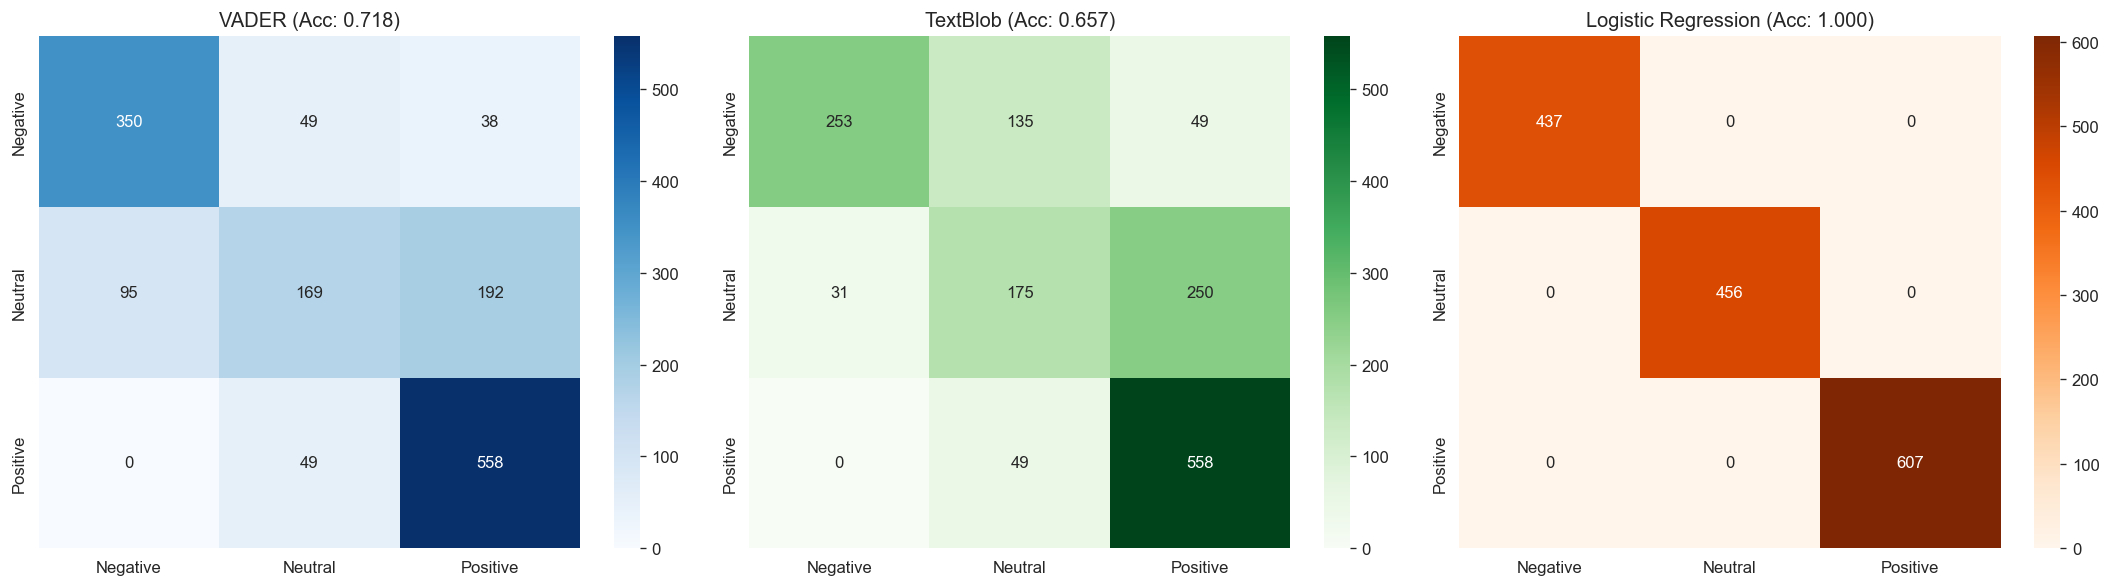

In [9]:
labels = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(df["true_sentiment"], df["vader_sentiment"]),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f"VADER (Acc: {vader_acc:.3f})")

sns.heatmap(confusion_matrix(df["true_sentiment"], df["textblob_sentiment"]),
            annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f"TextBlob (Acc: {tb_acc:.3f})")

sns.heatmap(confusion_matrix(df["true_sentiment"], df["lr_sentiment"]),
            annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title(f"Logistic Regression (Acc: {lr_acc:.3f})")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 8. ROC Curves

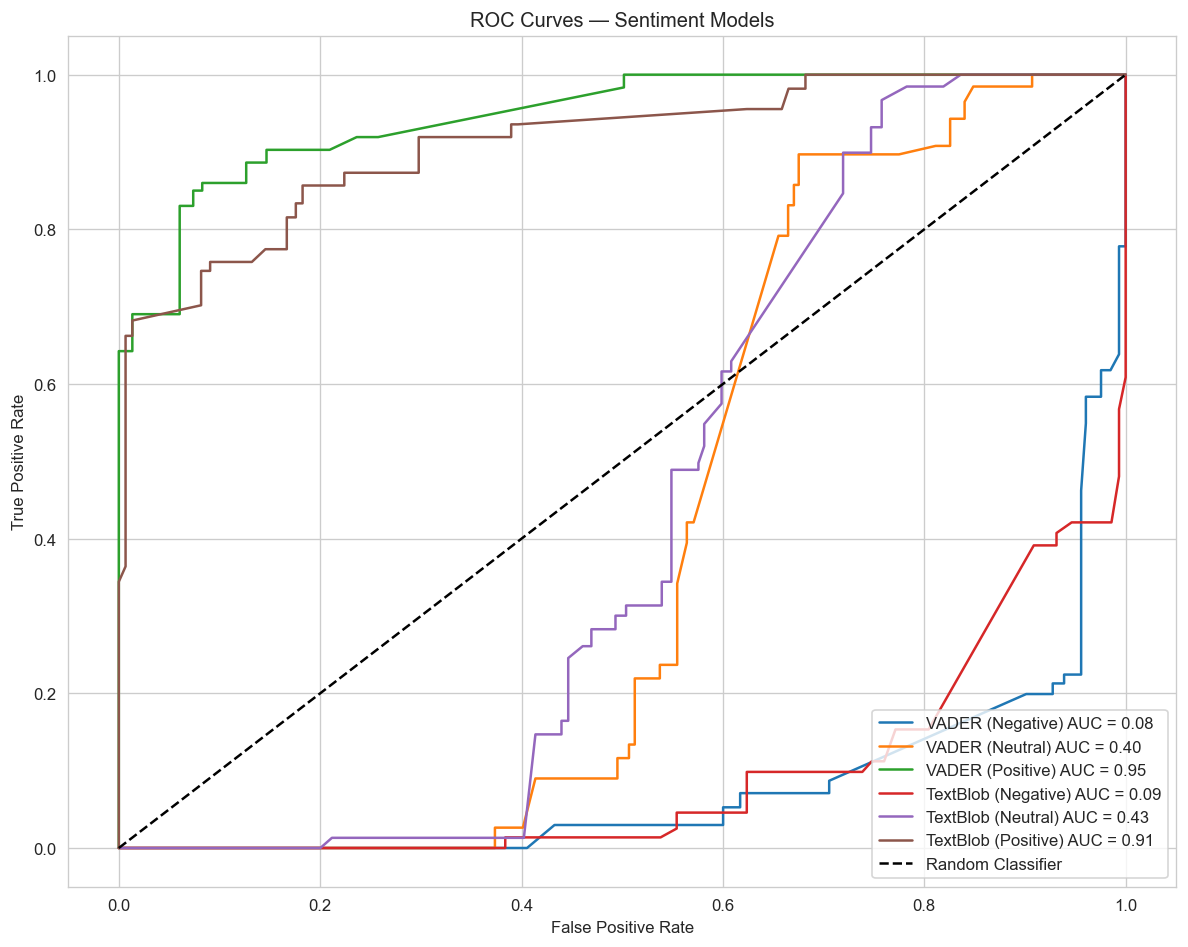

In [10]:
lb = LabelBinarizer()
y_bin = lb.fit_transform(df["true_sentiment"])

fig, ax = plt.subplots(figsize=(10, 8))

for name, scores_col in [("VADER", "vader_score"), ("TextBlob", "textblob_polarity")]:
    for i, cls in enumerate(lb.classes_):
        fpr, tpr, _ = roc_curve(y_bin[:, i], df[scores_col])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{name} ({cls}) AUC = {roc_auc:.2f}")

ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Sentiment Models")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 9. Sentiment Distribution

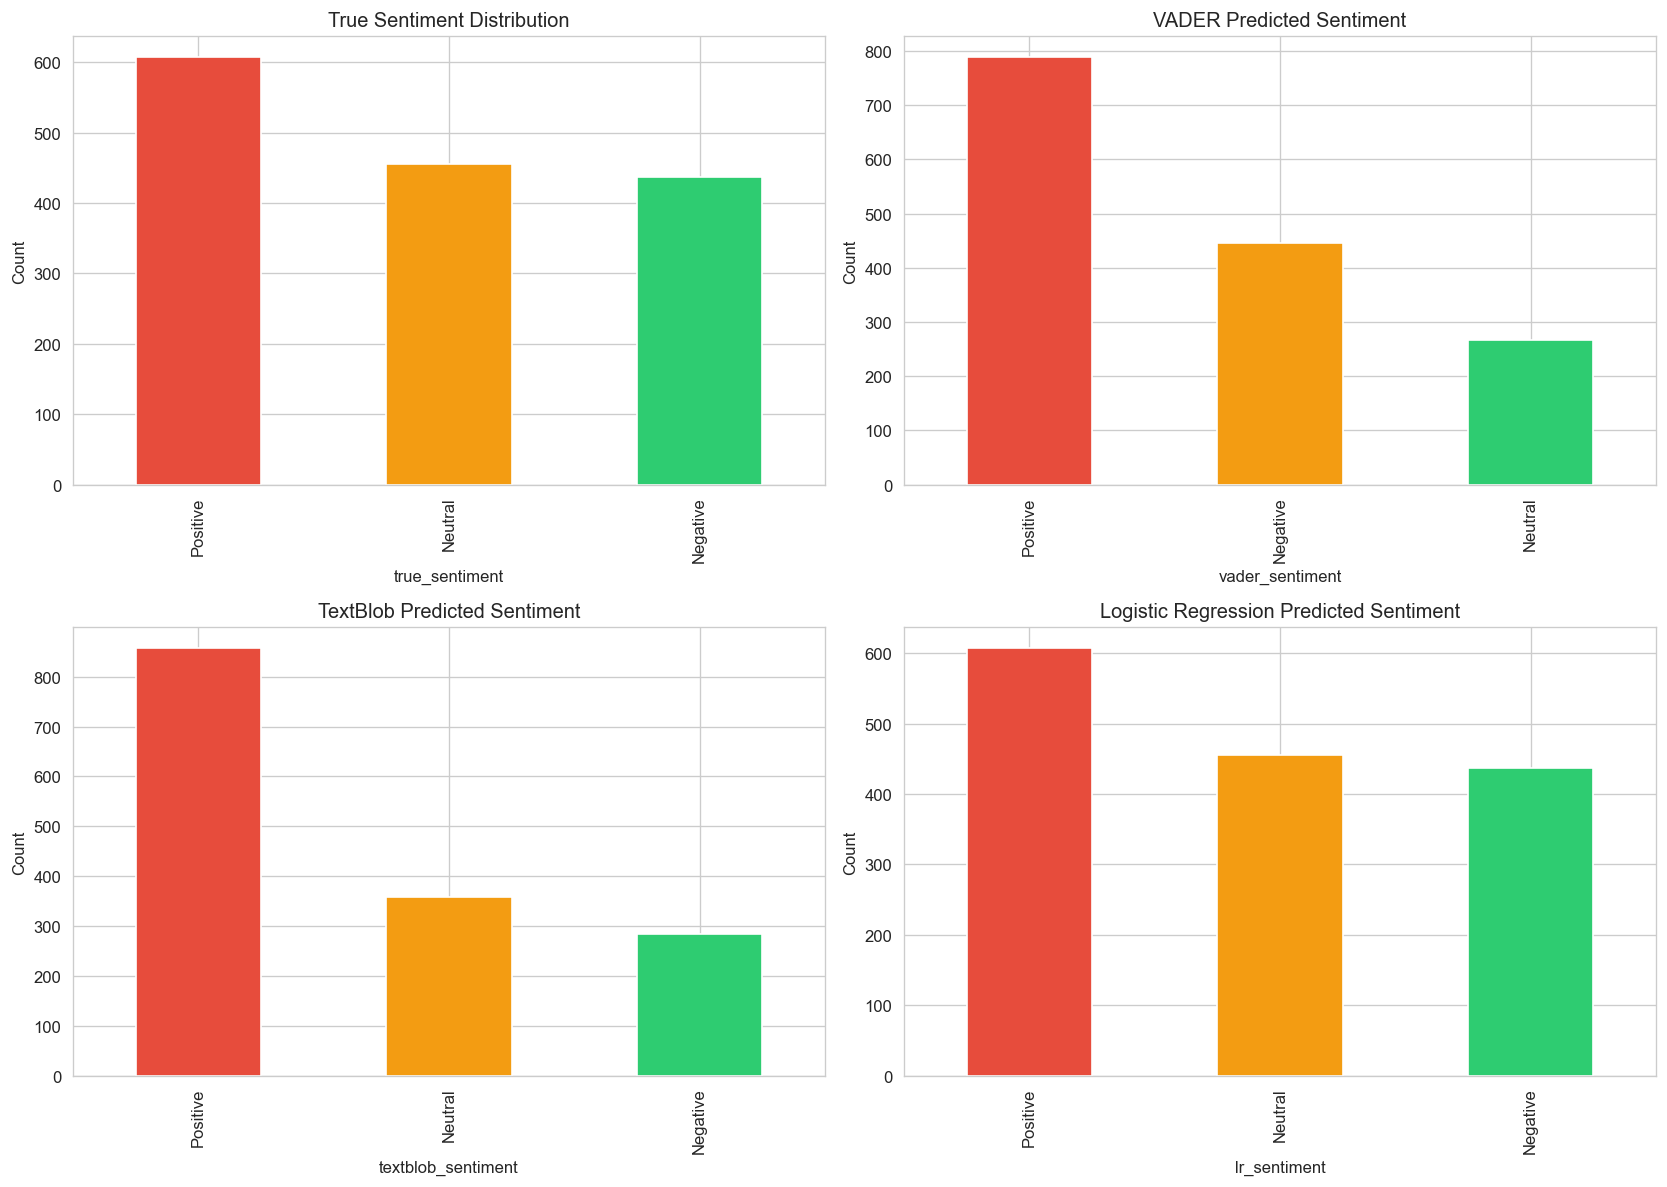

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["true_sentiment"].value_counts().plot(
    kind="bar", ax=axes[0, 0], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[0, 0].set_title("True Sentiment Distribution")
axes[0, 0].set_ylabel("Count")

df["vader_sentiment"].value_counts().plot(
    kind="bar", ax=axes[0, 1], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[0, 1].set_title("VADER Predicted Sentiment")
axes[0, 1].set_ylabel("Count")

df["textblob_sentiment"].value_counts().plot(
    kind="bar", ax=axes[1, 0], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[1, 0].set_title("TextBlob Predicted Sentiment")
axes[1, 0].set_ylabel("Count")

df["lr_sentiment"].value_counts().plot(
    kind="bar", ax=axes[1, 1], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[1, 1].set_title("Logistic Regression Predicted Sentiment")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 10. Word Clouds

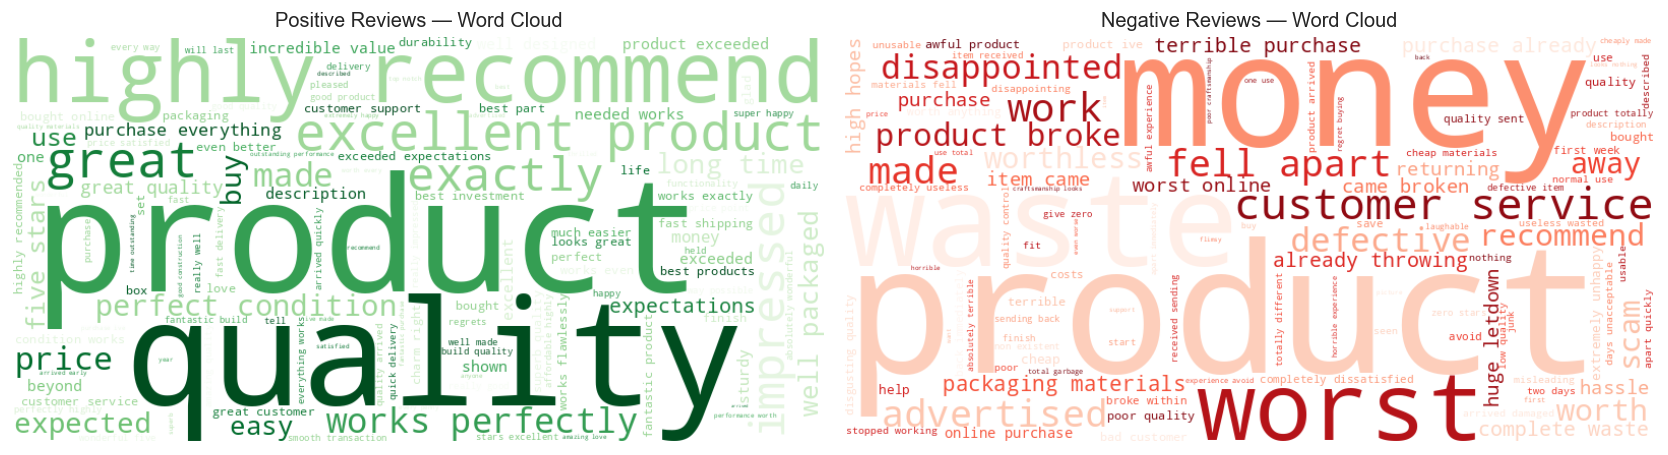

In [12]:
positive_text = " ".join(df[df["true_sentiment"] == "Positive"]["cleaned_text"])
negative_text = " ".join(df[df["true_sentiment"] == "Negative"]["cleaned_text"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(positive_text), interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Reviews — Word Cloud")

axes[1].imshow(WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(negative_text), interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative Reviews — Word Cloud")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

### 11. Save Results

In [13]:
df.to_csv(DATA_DIR / "reviews_sentiment.csv", index=False)
print("Saved to data/reviews_sentiment.csv")

summary = df["vader_sentiment"].value_counts().reset_index()
summary.columns = ["Sentiment", "Count"]
summary["Percentage"] = (summary["Count"] / summary["Count"].sum() * 100).round(1)
summary.to_csv(OUTPUT_DIR / "sentiment_summary.csv", index=False)
print("\nSentiment Summary:")
summary

Saved to data/reviews_sentiment.csv

Sentiment Summary:


,Sentiment,Count,Percentage
0,Positive,788,52.5
1,Negative,445,29.7
2,Neutral,267,17.8
